# DeepLab old baseline reproduction on `kurgans-dataset/segmentation_dataset`

Этот notebook запускает old-style recipe из `all_class_baseline.ipynb`, но через clean scripts модуля `03_multiclass_segmentation_deeplab`.

Цель: проверить, воспроизводится ли сильная 5-class DeepLab линия на текущем Kaggle dataset:

`/kaggle/input/datasets/matanerdy/kurgans-dataset/segmentation_dataset/segmentation_dataset`

Recipe, который воспроизводим:

- DeepLabV3+ / ResNet34
- 6 classes: background + 5 archaeology classes
- metadata filtering: `max_crop_size=2048`, `max_objects_in_patch=40`, `touches_border=False`
- manual val regions from `all_class_baseline.ipynb`
- CE + Dice: `ce_weight=0.7`, `dice_weight=0.3`
- class weights: `[0.2, 1.0, 1.0, 1.4, 1.8, 1.8]`
- Adam, `lr=1e-4`
- ReduceLROnPlateau
- early stopping patience 12
- best checkpoint by `val_mean_fg_iou`

Notebook не содержит training logic: он только вызывает `scripts/train.py`, `scripts/evaluate.py`, `scripts/visualize_predictions.py`.

In [46]:
from pathlib import Path
import os
import subprocess
import sys

import torch

print('python:', sys.version)
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.4.1+cu118
cuda available: True
gpu: Tesla P100-PCIE-16GB


## Clone or update repository

In [47]:
REPO_URL = os.environ.get('REPO_URL', 'https://github.com/MataNerdy/Geodata_Archaeology_CV.git')
BRANCH = os.environ.get('BRANCH', 'main')
REPO_DIR = Path('/kaggle/working/Geodata_Archaeology_CV')

if REPO_DIR.exists():
    print('Repo already exists. Pulling latest changes...')
    subprocess.run(['git', 'fetch', 'origin'], cwd=REPO_DIR, check=True)
    subprocess.run(['git', 'checkout', BRANCH], cwd=REPO_DIR, check=True)
    subprocess.run(['git', 'pull', 'origin', BRANCH], cwd=REPO_DIR, check=True)
else:
    print('Cloning repo...')
    subprocess.run(['git', 'clone', '--branch', BRANCH, REPO_URL, str(REPO_DIR)], check=True)

SEG_DIR = REPO_DIR / '03_multiclass_segmentation_deeplab'
assert SEG_DIR.exists(), SEG_DIR
os.environ['PYTHONPATH'] = str(SEG_DIR) + os.pathsep + os.environ.get('PYTHONPATH', '')
print('Using SEG_DIR:', SEG_DIR)
subprocess.run(['git', 'log', '--oneline', '-3'], cwd=REPO_DIR, check=True)

Repo already exists. Pulling latest changes...


From https://github.com/MataNerdy/Geodata_Archaeology_CV
   e7ac67f..44d2026  main       -> origin/main
Already on 'main'


Your branch is behind 'origin/main' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
Updating e7ac67f..44d2026
Fast-forward
 03_multiclass_segmentation_deeplab/utils/splits.py | 23 ++++++++++------------
 1 file changed, 10 insertions(+), 13 deletions(-)
Using SEG_DIR: /kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab
44d2026 sota pipeline
e7ac67f sota pipeline
f184c2c sota pipeline


From https://github.com/MataNerdy/Geodata_Archaeology_CV
 * branch            main       -> FETCH_HEAD


CompletedProcess(args=['git', 'log', '--oneline', '-3'], returncode=0)

## Install/check dependencies

In [48]:
# Kaggle images may not include segmentation_models_pytorch by default.
try:
    import segmentation_models_pytorch as smp
    import cv2
    import shapely
    print('segmentation_models_pytorch:', smp.__version__)
except Exception as exc:
    print('Installing missing requirements because import failed:', repr(exc))
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(SEG_DIR / 'requirements.txt')], check=True)
    import segmentation_models_pytorch as smp
    print('segmentation_models_pytorch:', smp.__version__)

segmentation_models_pytorch: 0.3.4


## Resolve dataset path

In [49]:
def valid_data_root(path: Path) -> bool:
    return (path / 'metadata.csv').exists() and (path / 'images').is_dir() and (path / 'masks').is_dir()

# Prefer the current project Kaggle dataset. Keep env override for re-runs.
candidates = []
if os.environ.get('DATA_ROOT'):
    candidates.append(Path(os.environ['DATA_ROOT']))
candidates.extend([
    Path('/kaggle/input/datasets/matanerdy/kurgans-dataset/segmentation_dataset/segmentation_dataset'),
    Path('/kaggle/input/datasets/matanerdy/kurgans-dataset/segmentation_dataset'),
    Path('/kaggle/input/kurgans-dataset/segmentation_dataset/segmentation_dataset'),
    Path('/kaggle/input/kurgans-dataset/segmentation_dataset'),
])

DATA_ROOT = next((p for p in candidates if valid_data_root(p)), None)
if DATA_ROOT is None:
    raise FileNotFoundError('Could not find dataset root. Set DATA_ROOT to a folder with metadata.csv/images/masks.')

RUN_ROOT = Path(os.environ.get('RUN_ROOT', str(SEG_DIR / 'runs')))
OUT_DIR = RUN_ROOT / 'multiclass' / 'archaeology_5class_old_baseline_resnet34'
SMOKE_OUT_DIR = RUN_ROOT / 'multiclass' / 'archaeology_5class_old_baseline_smoke'

print('DATA_ROOT:', DATA_ROOT)
print('RUN_ROOT:', RUN_ROOT)
print('OUT_DIR:', OUT_DIR)

DATA_ROOT: /kaggle/input/datasets/matanerdy/kurgans-dataset/segmentation_dataset/segmentation_dataset
RUN_ROOT: /kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs
OUT_DIR: /kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34


## Sanity check metadata and old validation regions

Expected old-baseline split after filtering was `train=2656`, `val=223` on the old dataset copy. On `kurgans-dataset/segmentation_dataset` counts should be very close, but this cell prints the actual values before training.

In [50]:
import pandas as pd
from IPython.display import display

OLD_VAL_REGIONS = [
    '005_ЛУБНО',
    '012_ЛИХУША',
    '008_СЕЛЯНЕ',
    '011_РУНА',
    '014_СТРЕКАЛОВКА',
    '016_ЗОЛОТАРЕВКА',
    '089_Костомаровское',
    '044_ГОЧЕВО',
]
VAL_REGIONS = ','.join(OLD_VAL_REGIONS)

meta = pd.read_csv(DATA_ROOT / 'metadata.csv', dtype={'sample_id': str})
print('raw rows:', len(meta))
print('columns:', list(meta.columns))

if 'class_name' in meta.columns:
    print('\nclass_name counts')
    display(meta['class_name'].value_counts())
if 'modality' in meta.columns:
    print('\nmodality counts')
    display(meta['modality'].value_counts())

present_regions = set(meta['region'].astype(str))
missing_regions = [region for region in OLD_VAL_REGIONS if region not in present_regions]
if missing_regions:
    raise ValueError(f'Old validation regions are absent from metadata: {missing_regions}')

print('\nold val region counts')
display(meta[meta['region'].isin(OLD_VAL_REGIONS)]['region'].value_counts())

raw rows: 3260
columns: ['sample_id', 'region', 'modality', 'raster_file', 'source_file', 'class_name', 'class_id', 'class_label_ru', 'n_objects_in_patch', 'classes_in_patch', 'height', 'width', 'crop_size', 'obj_w_px', 'obj_h_px', 'target_fits_inside', 'touches_border', 'used_crs_fallback', 'mask_bg_pixels', 'mask_kurgany_tselye_pixels', 'has_kurgany_tselye', 'mask_kurgany_povrezhdennye_pixels', 'has_kurgany_povrezhdennye', 'mask_gorodishcha_pixels', 'has_gorodishcha', 'mask_fortifikatsii_pixels', 'has_fortifikatsii', 'mask_arkhitektury_pixels', 'has_arkhitektury']

class_name counts


class_name
kurgany_povrezhdennye    1822
kurgany_tselye            669
fortifikatsii             473
arkhitektury              218
gorodishcha                78
Name: count, dtype: int64


modality counts


modality
Ae      1274
SpOr     976
Li       934
Or        76
Name: count, dtype: int64


old val region counts


region
044_ГОЧЕВО            112
008_СЕЛЯНЕ             92
005_ЛУБНО              10
012_ЛИХУША              6
014_СТРЕКАЛОВКА         3
016_ЗОЛОТАРЕВКА         2
011_РУНА                1
089_Костомаровское      1
Name: count, dtype: int64

## Old recipe config sanity check

In [51]:
import yaml

config_path = SEG_DIR / 'configs' / 'archaeology_5class_old_baseline.yaml'
assert config_path.exists(), config_path
config = yaml.safe_load(config_path.read_text())
print(yaml.safe_dump(config, allow_unicode=True, sort_keys=False))

data_root: ../datasets/segmentation_dataset
out_dir: runs/multiclass/archaeology_5class_old_baseline_resnet34
task: archaeology_5class
encoder: resnet34
encoder_weights: null
epochs: 80
patience: 12
batch_size: 16
lr: 0.0001
weight_decay: 0.0
optimizer: adam
scheduler: plateau
scheduler_factor: 0.5
scheduler_patience: 5
grad_clip_norm: 1.0
image_size: 256
split: custom_regions
val_regions: 005_ЛУБНО,012_ЛИХУША,008_СЕЛЯНЕ,011_РУНА,014_СТРЕКАЛОВКА,016_ЗОЛОТАРЕВКА,044_ГОЧЕВО
val_fraction: 0.2
modalities:
- Li
- Ae
- SpOr
- Or
class_weights:
- 0.2
- 1.0
- 1.0
- 1.4
- 1.8
- 1.8
ce_weight: 0.7
dice_weight: 0.3
num_workers: 2
seed: 42
threshold: 0.5
save_samples: 8
use_weighted_sampler: false
sampler_mode: class_name
use_metadata_filtering: true
max_crop_size: 2048
max_objects_in_patch: 40
allowed_classes: kurgany_tselye,kurgany_povrezhdennye,gorodishcha,fortifikatsii,arkhitektury
exclude_touches_border: true
min_foreground_pixels: 1



## Smoke run

Default: run a 2-epoch smoke test first. Set `RUN_SMOKE=0` in notebook environment to skip.

In [52]:
RUN_SMOKE = os.environ.get('RUN_SMOKE', '1') == '1'
if RUN_SMOKE:
    subprocess.run([
        sys.executable, 'scripts/train.py',
        '--config', 'configs/archaeology_5class_old_baseline.yaml',
        '--data-root', str(DATA_ROOT),
        '--out-dir', str(SMOKE_OUT_DIR),
        '--epochs', '2',
        '--batch-size', '2',
        '--num-workers', '0',
        '--save-samples', '2',
    ], cwd=SEG_DIR, check=True)
else:
    print('Smoke skipped')

Metadata filtering: 3260 -> 2879 samples
Device: cuda
Train samples: 2656 | Val samples: 223
Validation samples by region/modality:
         region modality  samples
      005_ЛУБНО       Li       10
     008_СЕЛЯНЕ       Ae       71
     008_СЕЛЯНЕ       Li       21
       011_РУНА       Li        1
     012_ЛИХУША       Li        6
014_СТРЕКАЛОВКА       Li        3
016_ЗОЛОТАРЕВКА     SpOr        1
     044_ГОЧЕВО       Ae      108
     044_ГОЧЕВО     SpOr        2
Epoch 001: train_loss=1.2160 val_loss=1.1051 val_mean_fg_iou=0.0803
Saved best_model.pth (val_mean_fg_iou=0.0803)
Epoch 002: train_loss=1.1456 val_loss=1.0675 val_mean_fg_iou=0.0850
Saved best_model.pth (val_mean_fg_iou=0.0850)


## Full old-baseline reproduction training

Default: run full training. Set `RUN_TRAIN=0` if you only want to inspect setup or evaluate an already existing checkpoint.

In [53]:
RUN_TRAIN = os.environ.get('RUN_TRAIN', '1') == '1'
if RUN_TRAIN:
    subprocess.run([
        sys.executable, 'scripts/train.py',
        '--config', 'configs/archaeology_5class_old_baseline.yaml',
        '--data-root', str(DATA_ROOT),
        '--out-dir', str(OUT_DIR),
    ], cwd=SEG_DIR, check=True)
else:
    print('Training skipped')

Metadata filtering: 3260 -> 2879 samples
Device: cuda
Train samples: 2656 | Val samples: 223
Validation samples by region/modality:
         region modality  samples
      005_ЛУБНО       Li       10
     008_СЕЛЯНЕ       Ae       71
     008_СЕЛЯНЕ       Li       21
       011_РУНА       Li        1
     012_ЛИХУША       Li        6
014_СТРЕКАЛОВКА       Li        3
016_ЗОЛОТАРЕВКА     SpOr        1
     044_ГОЧЕВО       Ae      108
     044_ГОЧЕВО     SpOr        2
Epoch 001: train_loss=1.0966 val_loss=1.2766 val_mean_fg_iou=0.0748
Saved best_model.pth (val_mean_fg_iou=0.0748)
Epoch 002: train_loss=0.9307 val_loss=1.2740 val_mean_fg_iou=0.0815
Saved best_model.pth (val_mean_fg_iou=0.0815)
Epoch 003: train_loss=0.8682 val_loss=1.4008 val_mean_fg_iou=0.0785
Epoch 004: train_loss=0.8002 val_loss=1.1139 val_mean_fg_iou=0.0914
Saved best_model.pth (val_mean_fg_iou=0.0914)
Epoch 005: train_loss=0.7576 val_loss=1.0926 val_mean_fg_iou=0.0729
Epoch 006: train_loss=0.6959 val_loss=1.1881 val_m

## Evaluate pixel and object metrics

In [54]:
checkpoint = OUT_DIR / 'best_model.pth'
if checkpoint.exists():
    subprocess.run([
        sys.executable, 'scripts/evaluate.py',
        '--checkpoint', str(checkpoint),
        '--data-root', str(DATA_ROOT),
        '--out-dir', str(OUT_DIR),
        '--eval-mode', 'pixel',
    ], cwd=SEG_DIR, check=True)
    subprocess.run([
        sys.executable, 'scripts/evaluate.py',
        '--checkpoint', str(checkpoint),
        '--data-root', str(DATA_ROOT),
        '--out-dir', str(OUT_DIR),
        '--eval-mode', 'object',
        '--object-iou-threshold', '0.3',
        '--min-component-area', '8',
    ], cwd=SEG_DIR, check=True)
else:
    print('Checkpoint not found yet:', checkpoint)

/kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/scripts/evaluate.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(args

{
  "iou_background": 0.7091062664985657,
  "dice_background": 0.8297977447509766,
  "iou_kurgany_tselye": 0.11651699244976044,
  "dice_kurgany_tselye": 0.20871512591838837,
  "iou_kurgany_povrezhdennye": 0.25589412450790405,
  "dice_kurgany_povrezhdennye": 0.40750908851623535,
  "iou_gorodishcha": 0.0008824963588267565,
  "dice_gorodishcha": 0.0017634364776313305,
  "iou_fortifikatsii": 0.2486966848373413,
  "dice_fortifikatsii": 0.3983300030231476,
  "iou_arkhitektury": 0.0,
  "dice_arkhitektury": 0.0,
  "mean_fg_iou": 0.12439806759357452,
  "mean_fg_dice": 0.2032635509967804,
  "pixel_accuracy": 0.7173757553100586
}


/kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/scripts/evaluate.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(args

{
  "object_precision": 0.9135802456603838,
  "object_recall": 0.3973747014335473,
  "object_f1": 0.5538457309105447,
  "weighted_competition_f1": 0.4487949008397087,
  "object_iou_threshold": 0.3
}


## Visualize predictions

In [55]:
if checkpoint.exists():
    subprocess.run([
        sys.executable, 'scripts/visualize_predictions.py',
        '--checkpoint', str(checkpoint),
        '--data-root', str(DATA_ROOT),
        '--output', str(OUT_DIR / 'prediction_examples.png'),
        '--max-samples', '8',
    ], cwd=SEG_DIR, check=True)
else:
    print('Checkpoint not found yet:', checkpoint)

/kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/scripts/visualize_predictions.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = tor

Saved predictions to /kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34/prediction_examples.png


## Results and quick comparison

Reference from old notebook evaluation:

- `weighted_competition_f1 ~= 0.741`
- reference checkpoint: `deeplab_5class_43_best.pth`

This notebook trains/evaluates the old recipe on the current `kurgans-dataset/segmentation_dataset`; use the resulting pixel/object metrics to see whether the recipe itself reproduces the old behavior.


history.csv


,epoch,train_loss,train_ce_loss,train_dice_loss,train_iou_background,train_dice_background,train_iou_kurgany_tselye,train_dice_kurgany_tselye,train_iou_kurgany_povrezhdennye,train_dice_kurgany_povrezhdennye,...,val_dice_kurgany_povrezhdennye,val_iou_gorodishcha,val_dice_gorodishcha,val_iou_fortifikatsii,val_dice_fortifikatsii,val_iou_arkhitektury,val_dice_arkhitektury,val_mean_fg_iou,val_mean_fg_dice,val_pixel_accuracy
43,44,0.110155,0.062232,0.221976,0.952072,0.975448,0.891888,0.942855,0.916619,0.956496,...,0.398579,0.000672,0.001342,0.240643,0.387932,0.0,0.0,0.119688,0.196636,0.759267
44,45,0.109251,0.061305,0.221124,0.952823,0.975841,0.892474,0.943182,0.917541,0.956997,...,0.416704,0.003201,0.006382,0.233817,0.379015,0.0,0.0,0.121838,0.199729,0.727224
45,46,0.109194,0.061524,0.220423,0.952802,0.975831,0.893763,0.943901,0.917807,0.957142,...,0.415922,0.001465,0.002927,0.243188,0.391233,0.0,0.0,0.123579,0.201876,0.737725
46,47,0.105450,0.059379,0.212949,0.954182,0.976554,0.895059,0.944624,0.920001,0.958334,...,0.412482,0.000653,0.001306,0.209865,0.346923,0.0,0.0,0.116061,0.191768,0.753128
47,48,0.108278,0.060236,0.220377,0.954315,0.976623,0.895163,0.944682,0.920208,0.958446,...,0.410566,0.001344,0.002685,0.221016,0.362019,0.0,0.0,0.118938,0.195995,0.755041



evaluation.csv


,iou_background,dice_background,iou_kurgany_tselye,dice_kurgany_tselye,iou_kurgany_povrezhdennye,dice_kurgany_povrezhdennye,iou_gorodishcha,dice_gorodishcha,iou_fortifikatsii,dice_fortifikatsii,iou_arkhitektury,dice_arkhitektury,mean_fg_iou,mean_fg_dice,pixel_accuracy
0,0.709106,0.829798,0.116517,0.208715,0.255894,0.407509,0.000882,0.001763,0.248697,0.39833,0.0,0.0,0.124398,0.203264,0.717376



evaluation_object.csv


,object_precision,object_recall,object_f1,weighted_competition_f1,object_iou_threshold
0,0.91358,0.397375,0.553846,0.448795,0.3



competition_metric.csv


,class_name,weight,tp,fp,fn,num_predictions,num_ground_truth,precision,recall,f1
0,kurgany_povrezhdennye,27.8,500,1,770,501,1270,0.998004,0.393701,0.564652
1,kurgany_tselye,22.2,124,14,219,138,343,0.898551,0.361516,0.515592
2,gorodishcha,16.7,9,26,0,35,9,0.257143,1.000000,0.409091
3,arkhitektury,11.1,0,2,0,2,0,0.000000,0.000000,0.000000
4,fortifikatsii,5.6,33,20,21,53,54,0.622641,0.611111,0.616822



summary.json
{
  "best_epoch": 36,
  "best_metric": 0.1565362513065338,
  "task": "archaeology_5class",
  "config": {
    "data_root": "/kaggle/input/datasets/matanerdy/kurgans-dataset/segmentation_dataset/segmentation_dataset",
    "out_dir": "/kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34",
    "task": "archaeology_5class",
    "encoder": "resnet34",
    "encoder_weights": null,
    "epochs": 80,
    "patience": 12,
    "batch_size": 16,
    "lr": 0.0001,
    "weight_decay": 0.0,
    "optimizer": "adam",
    "scheduler": "plateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    "grad_clip_norm": 1.0,
    "image_size": 256,
    "split": "custom_regions",
    "val_region": null,
    "val_regions": "005_ЛУБНО,012_ЛИХУША,008_СЕЛЯНЕ,011_РУНА,014_СТРЕКАЛОВКА,016_ЗОЛОТАРЕВКА,044_ГОЧЕВО",
    "val_fraction": 0.2,
    "modalities": [
      "Li",
      "Ae",
      "SpOr",
      "Or"
    ],
    "

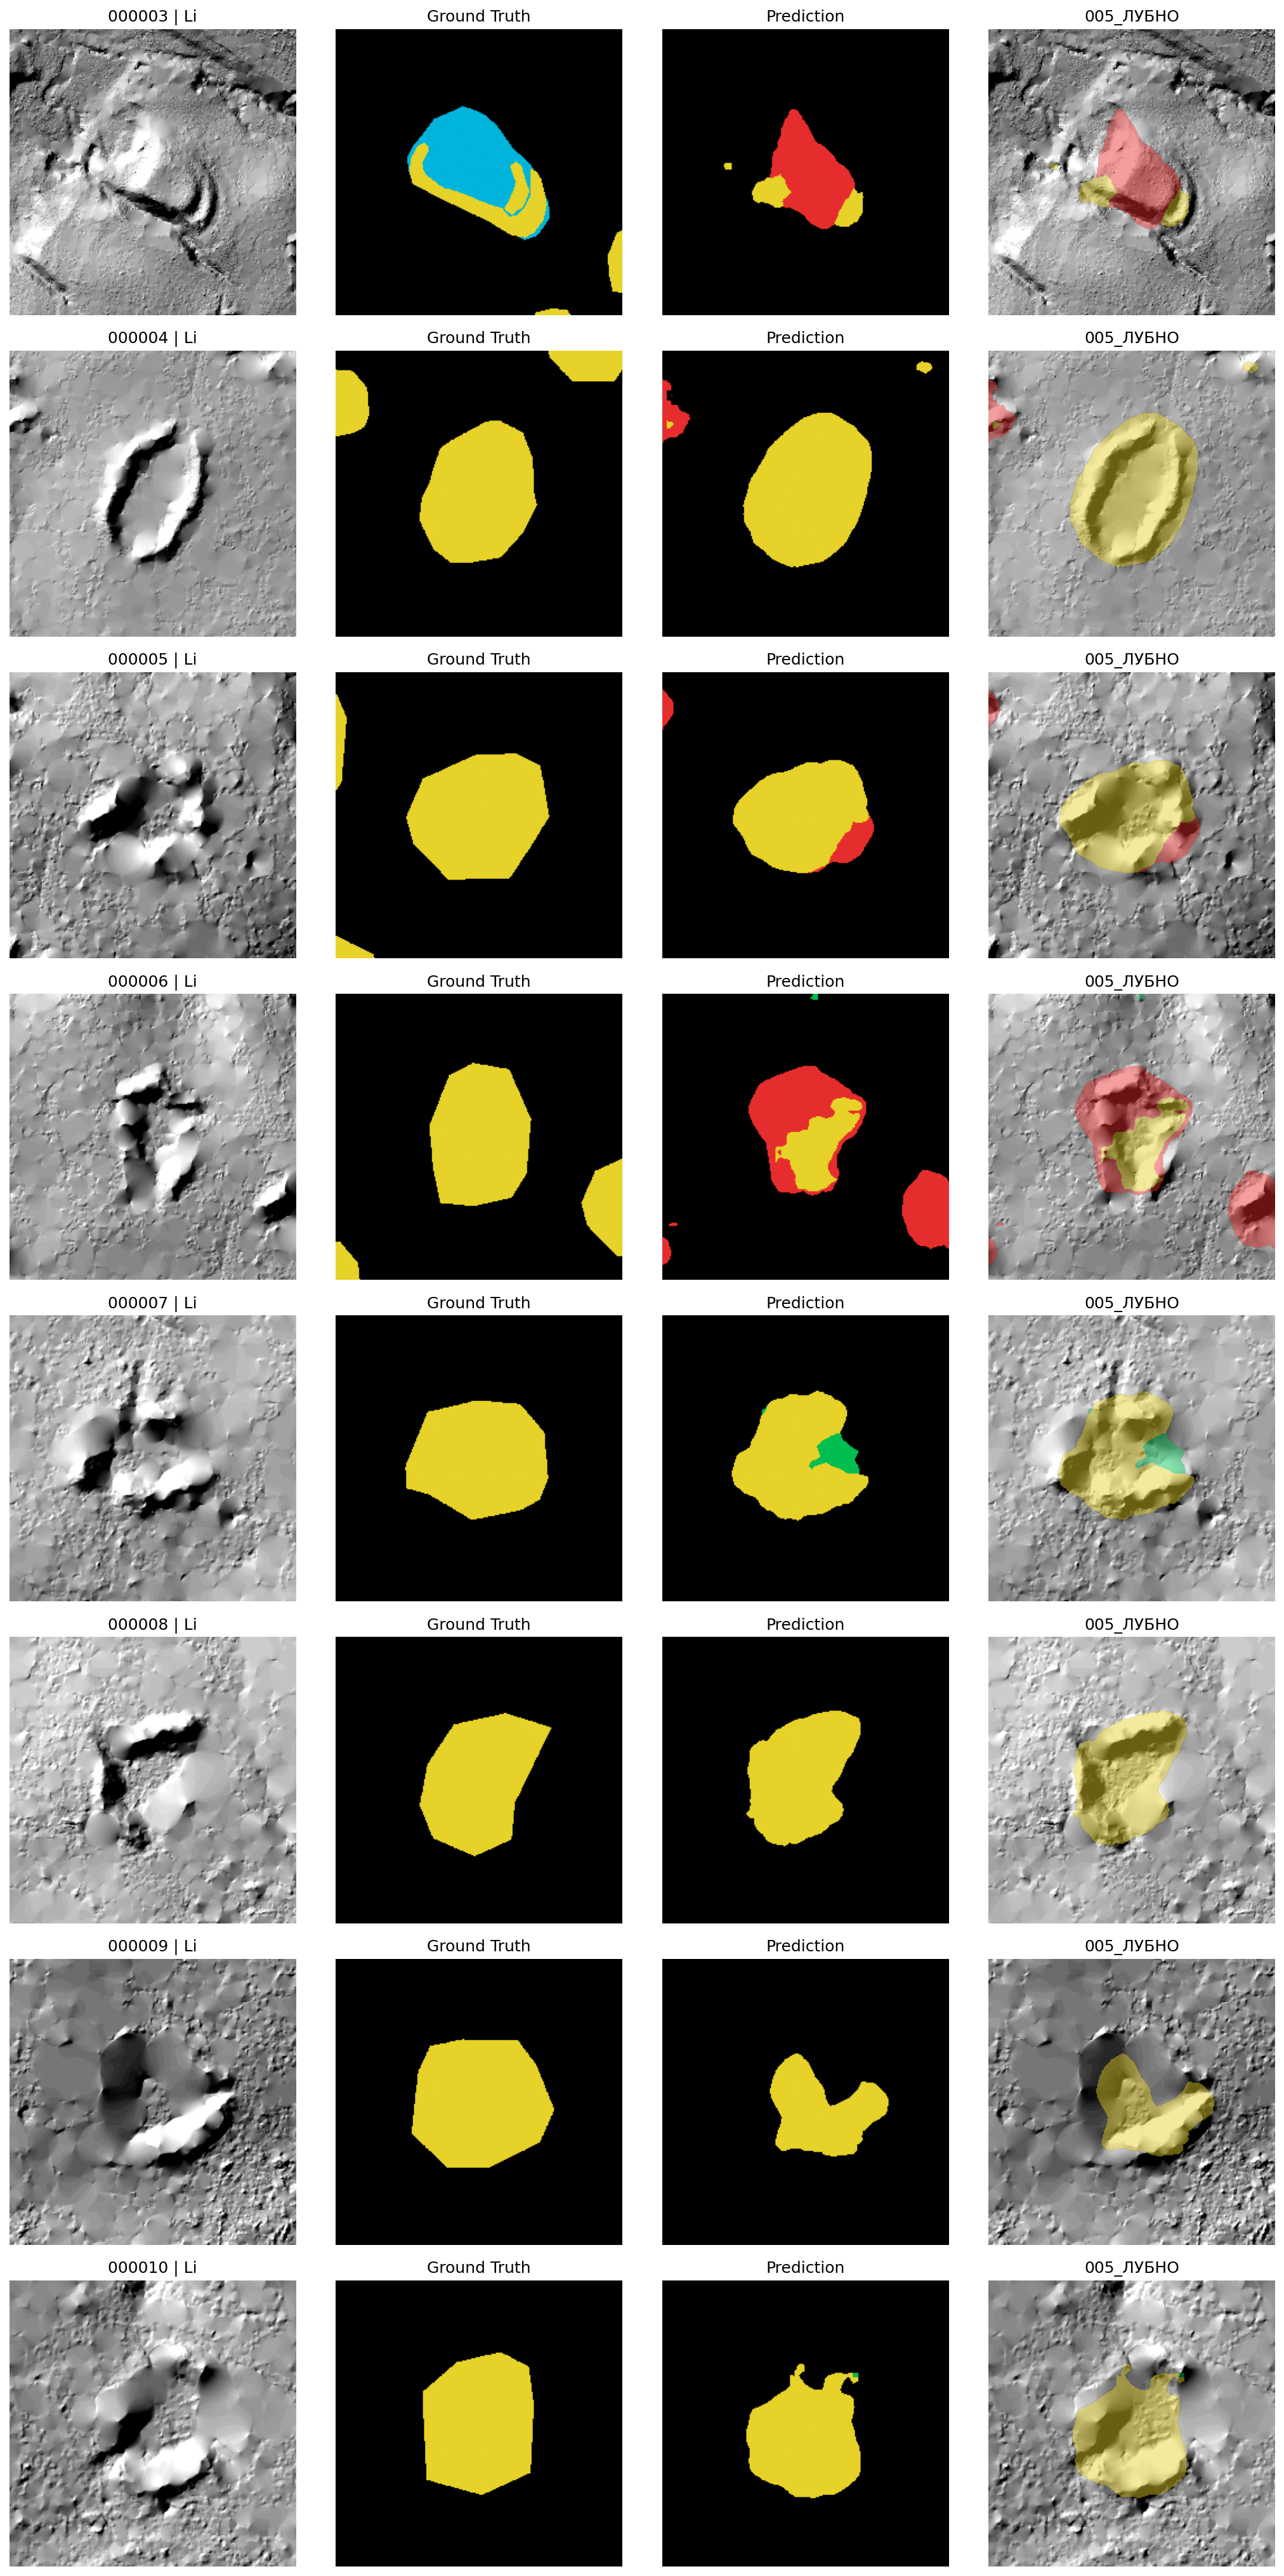

In [56]:
from IPython.display import display, Image
import json

for csv_name in ['history.csv', 'evaluation.csv', 'evaluation_object.csv', 'competition_metric.csv']:
    path = OUT_DIR / csv_name
    if path.exists():
        print('\n' + csv_name)
        df = pd.read_csv(path)
        display(df.tail() if len(df) > 5 else df)

summary_path = OUT_DIR / 'summary.json'
if summary_path.exists():
    print('\nsummary.json')
    print(json.dumps(json.loads(summary_path.read_text()), ensure_ascii=False, indent=2)[:3000])

image_path = OUT_DIR / 'prediction_examples.png'
if image_path.exists():
    display(Image(filename=str(image_path)))

## Zip outputs

In [57]:
zip_path = Path('/kaggle/working/deeplab_old_baseline_reproduction_runs.zip')
if OUT_DIR.exists():
    subprocess.run(['zip', '-r', str(zip_path), str(OUT_DIR)], check=True)
    print('Saved:', zip_path)
else:
    print('Nothing to zip yet:', OUT_DIR)

  adding: kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34/ (stored 0%)
  adding: kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34/evaluation.json (deflated 60%)
  adding: kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34/confusion_matrix.csv (deflated 77%)
  adding: kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34/evaluation_object.json (deflated 64%)
  adding: kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34/per_class_iou.csv (deflated 32%)
  adding: kaggle/working/Geodata_Archaeology_CV/03_multiclass_segmentation_deeplab/runs/multiclass/archaeology_5class_old_baseline_resnet34/predictio